In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

from shared.config import *
from shared.metrics import (ids_evaluate,
                             tune_threshold_proba)
from shared.plots import (plot_confusion_matrix,
                           plot_pr_curve)

print(f"PyTorch version : {torch.__version__}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device          : {device}")

Config loaded successfully
PyTorch version : 2.10.0+cu128
Device          : cuda


In [2]:
# Cell 2 — Load splits
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)

X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(f"Train: {X_train.shape}")

Train: (5798977, 78)


In [3]:
# Cell 3 — Scale + convert to tensors
scaler_dl    = StandardScaler()
X_tr_scaled  = scaler_dl.fit_transform(X_train)
X_va_scaled  = scaler_dl.transform(X_val)
X_te_scaled  = scaler_dl.transform(X_test)

X_tr_t = torch.tensor(X_tr_scaled, dtype=torch.float32)
X_va_t = torch.tensor(X_va_scaled, dtype=torch.float32)
X_te_t = torch.tensor(X_te_scaled, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32)
y_va_t = torch.tensor(y_val.values,   dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=MLP_BATCH, shuffle=True,
    num_workers=0
)

with open("models/dl/scaler_dl.pkl", "wb") as f:
    pickle.dump(scaler_dl, f)
print("Tensors ready")

Tensors ready


In [4]:
# Cell 4 — MLP architecture
class MLP(nn.Module):
    """
    Multi-Layer Perceptron for IDS binary classification.
    Architecture: Input → 256 → 128 → 64 → 1
    Regularization: BatchNorm + Dropout
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze()

input_dim = X_tr_t.shape[1]
mlp       = MLP(input_dim).to(device)
optimizer = torch.optim.Adam(
    mlp.parameters(),
    lr=MLP_LR,
    weight_decay=1e-5
)
criterion = nn.BCELoss()

total_params = sum(p.numel() for p in mlp.parameters())
print(f"MLP architecture ready")
print(f"Input dim     : {input_dim}")
print(f"Total params  : {total_params:,}")
print(mlp)

MLP architecture ready
Input dim     : 78
Total params  : 62,209
MLP(
  (net): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
    (11): Sigmoid()
  )
)


In [5]:
# Cell 5 — Training loop
train_losses = []
val_losses   = []
best_val     = float("inf")

for epoch in range(MLP_EPOCHS):
    # Train
    mlp.train()
    batch_losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(mlp(Xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = float(np.mean(batch_losses))

    # Validate
    mlp.eval()
    with torch.no_grad():
        val_loss = criterion(
            mlp(X_va_t.to(device)),
            y_va_t.to(device)
        ).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 5 == 0 or epoch == MLP_EPOCHS - 1:
        print(f"Epoch {epoch+1:02d}/{MLP_EPOCHS} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(mlp.state_dict(), "models/dl/mlp_best.pt")

print(f"\nBest val loss: {best_val:.4f}")
print("Best weights saved")

Epoch 01/30 | Train: 0.0852 | Val: 0.0751
Epoch 06/30 | Train: 0.0754 | Val: 0.0740
Epoch 11/30 | Train: 0.0747 | Val: 0.0732
Epoch 16/30 | Train: 0.0745 | Val: 0.0728
Epoch 21/30 | Train: 0.0741 | Val: 0.0734
Epoch 26/30 | Train: 0.0738 | Val: 0.0723
Epoch 30/30 | Train: 0.0738 | Val: 0.0724

Best val loss: 0.0723
Best weights saved


In [6]:
# Free memory before heavy training
import gc
del splits
gc.collect()
print("Memory freed")

Memory freed


In [6]:
# Cell 6 — Load best weights + get probabilities
mlp.load_state_dict(torch.load("models/dl/mlp_best.pt"))
mlp.eval()

with torch.no_grad():
    proba_mlp_val  = mlp(X_va_t.to(device)).cpu().numpy()
    proba_mlp_test = mlp(X_te_t.to(device)).cpu().numpy()

th_mlp     = tune_threshold_proba(proba_mlp_val, y_val)
y_pred_mlp = (proba_mlp_test >= th_mlp).astype(int)

mlp_m = ids_evaluate("MLP", y_test.values,
                       proba_mlp_test,
                       y_pred_mlp, th_mlp)
print("MLP IDS metrics:")
for k, v in mlp_m.items():
    print(f"  {k}: {v}")

MLP IDS metrics:
  Model: MLP
  Balanced Acc: 0.9598
  F1 Macro: 0.9547
  MCC: 0.9097
  Attack Recall: 0.9496
  Benign Recall: 0.9699
  Attack Precision: 0.9181
  Benign Precision: 0.9819
  FAR: 0.0301
  FNR: 0.0504
  ROC-AUC: 0.9873
  PR-AUC: 0.9806


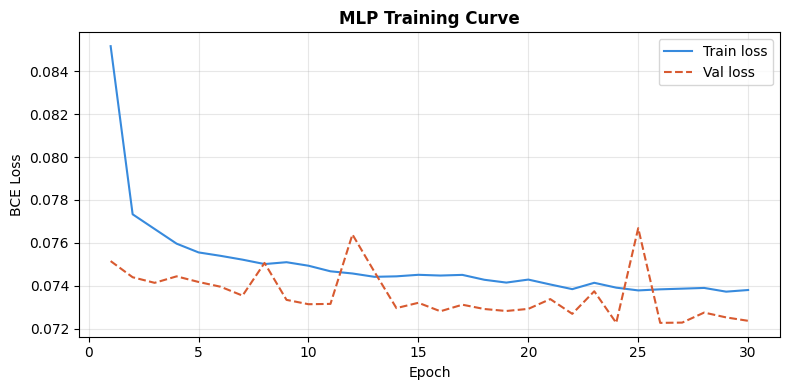

In [7]:
# Cell 7 — Training curve
fig, ax = plt.subplots(figsize=(8, 4))
epochs = range(1, MLP_EPOCHS + 1)
ax.plot(epochs, train_losses, color="#378ADD",
        label="Train loss")
ax.plot(epochs, val_losses,   color="#D85A30",
        label="Val loss", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("MLP Training Curve", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/graphs/04_mlp_loss.png", dpi=150)
plt.show()

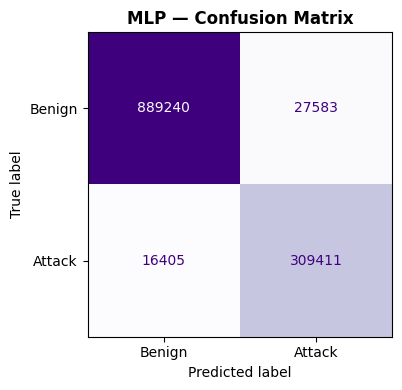

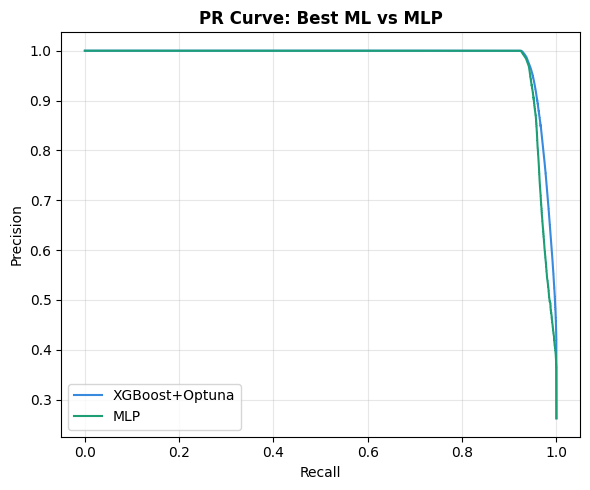

In [8]:
# Cell 8 — MLP confusion matrix + PR curve
plot_confusion_matrix(
    y_test.values, y_pred_mlp,
    title="MLP — Confusion Matrix",
    cmap="Purples",
    save_path="outputs/graphs/04_mlp_cm.png"
)

with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data = pickle.load(f)
optuna_proba = opt_data["proba_optuna"]

plot_pr_curve(
    y_test.values,
    {"XGBoost+Optuna": optuna_proba,
     "MLP"           : proba_mlp_test},
    title="PR Curve: Best ML vs MLP",
    save_path="outputs/graphs/04_ml_vs_dl_pr.png"
)

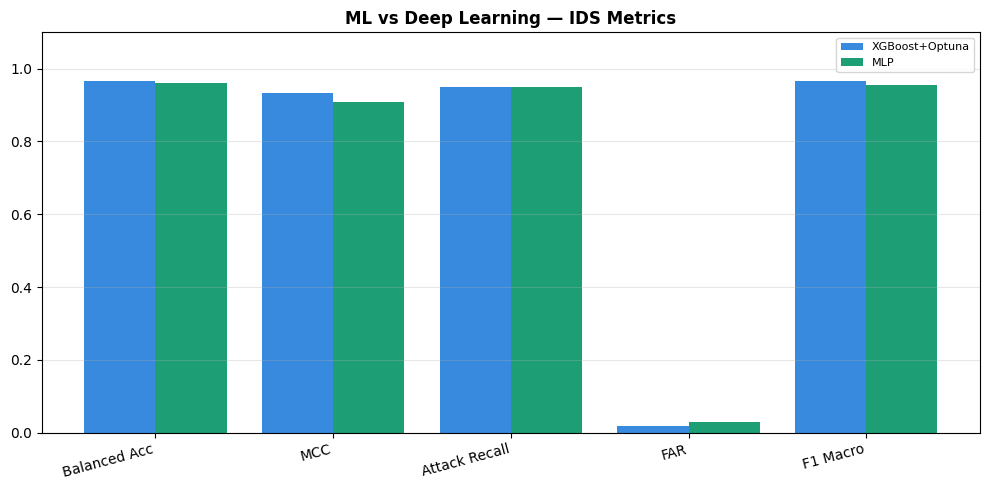

In [9]:
# Cell 9 — ML vs DL metric comparison
from shared.plots import plot_metrics_bar

with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data = pickle.load(f)
optuna_m = opt_data["optuna_m"]

KEY = ["Balanced Acc","MCC","Attack Recall","FAR","F1 Macro"]
plot_metrics_bar(
    {"XGBoost+Optuna": optuna_m, "MLP": mlp_m},
    KEY,
    title="ML vs Deep Learning — IDS Metrics",
    save_path="outputs/graphs/04_ml_vs_dl.png"
)

In [10]:
# Cell 10 — Save DL results
dl_data = {
    "mlp_m"           : mlp_m,
    "proba_mlp_test"  : proba_mlp_test,
    "proba_mlp_val"   : proba_mlp_val,
    "th_mlp"          : th_mlp,
    "train_losses"    : train_losses,
    "val_losses"      : val_losses,
}
with open("models/dl/dl_results.pkl", "wb") as f:
    pickle.dump(dl_data, f)

print("Notebook 04 complete — proceed to 05_hybrid_ensemble.ipynb")

Notebook 04 complete — proceed to 05_hybrid_ensemble.ipynb
